# util_timeline — GEMM vs attention latency (vLLM vs AccTTS)

One figure, from two nsys runs of the *same* forced-generation task
(problem 1, 16 beams, identical token counts):

* `p1_gen_vllm.nsys-rep` — baseline vLLM
* `p1_gen_ours.nsys-rep` — AccTTS (FD attention: `_paged_attn_stage1/stage2`)

**GEMM latency** is taken as the CUDA-graph replay time (the per-decode-step
graph is GEMM-dominated); **attention latency** is the per-op attention kernel
time.

In [ ]:
import sqlite3, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path('./nvidia_toolkit_data/util_timeline')
FIG_DIR = Path('./figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPS = {'vLLM': HERE / 'p1_gen_vllm.nsys-rep',
        'AccTTS': HERE / 'p1_gen_ours.nsys-rep'}

def ensure_sqlite(rep: Path) -> Path:
    db = rep.with_suffix('.sqlite')
    if not db.exists():
        print(f'exporting {db.name} (one-time) ...')
        subprocess.run(['nsys', 'export', '--type', 'sqlite',
                        '--force-overwrite=true', '--output', str(db), str(rep)],
                       check=True, capture_output=True)
    return db

DBS = {name: ensure_sqlite(rep) for name, rep in REPS.items()}
# COLORS = {'vLLM': '#648ace', 'AccTTS': '#ed7d31'}
DBS

{'vLLM': PosixPath('./nvidia_toolkit_data/util_timeline/p1_gen_vllm.sqlite'),
 'AccTTS': PosixPath('./nvidia_toolkit_data/util_timeline/p1_gen_ours.sqlite')}

In [2]:
def load_kernels(db):
    con = sqlite3.connect(db)
    df = pd.read_sql_query(
        'SELECT k.start, k.end, k.gridX, k.gridY, k.gridZ, s.value AS name '
        'FROM CUPTI_ACTIVITY_KIND_KERNEL k '
        'JOIN StringIds s ON k.demangledName = s.id', con)
    con.close()
    df['dur'] = df['end'] - df['start']
    df['blocks'] = df['gridX'] * df['gridY'] * df['gridZ']   # #thread blocks (CTAs)
    return df

def load_graphs(db):
    con = sqlite3.connect(db)
    df = pd.read_sql_query(
        'SELECT start, end FROM CUPTI_ACTIVITY_KIND_GRAPH_TRACE', con)
    con.close()
    return df

def binned(ts, val, nbins=1200):
    """Mean-bin `val` over `nbins` equal time windows of `ts` (must be sorted).
    Returns (bin-centre seconds relative to ts[0], per-bin mean)."""
    t0, t1 = ts[0], ts[-1]
    edges = np.linspace(t0, t1, nbins + 1)
    idx = np.clip(np.searchsorted(edges, ts, 'right') - 1, 0, nbins - 1)
    s = np.bincount(idx, val, nbins)
    c = np.bincount(idx, minlength=nbins)
    centers = (edges[:-1] + edges[1:]) / 2
    return (centers - t0) / 1e9, s / np.maximum(c, 1)

In [3]:
# Load both runs once.
DATA = {}
for name, db in DBS.items():
    DATA[name] = {'kernels': load_kernels(db), 'graphs': load_graphs(db)}
    print(f'{name}: {len(DATA[name]["kernels"])} kernels, '
          f'{len(DATA[name]["graphs"])} GEMM (graph) replays')

vLLM: 520220 kernels, 118784 GEMM (graph) replays


AccTTS: 627264 kernels, 118784 GEMM (graph) replays


## GEMM vs attention latency over time

**Colour = run** (vLLM / AccTTS), **line style = metric** (solid = GEMM latency
i.e. CUDA-graph replay time, dashed = attention-op time).

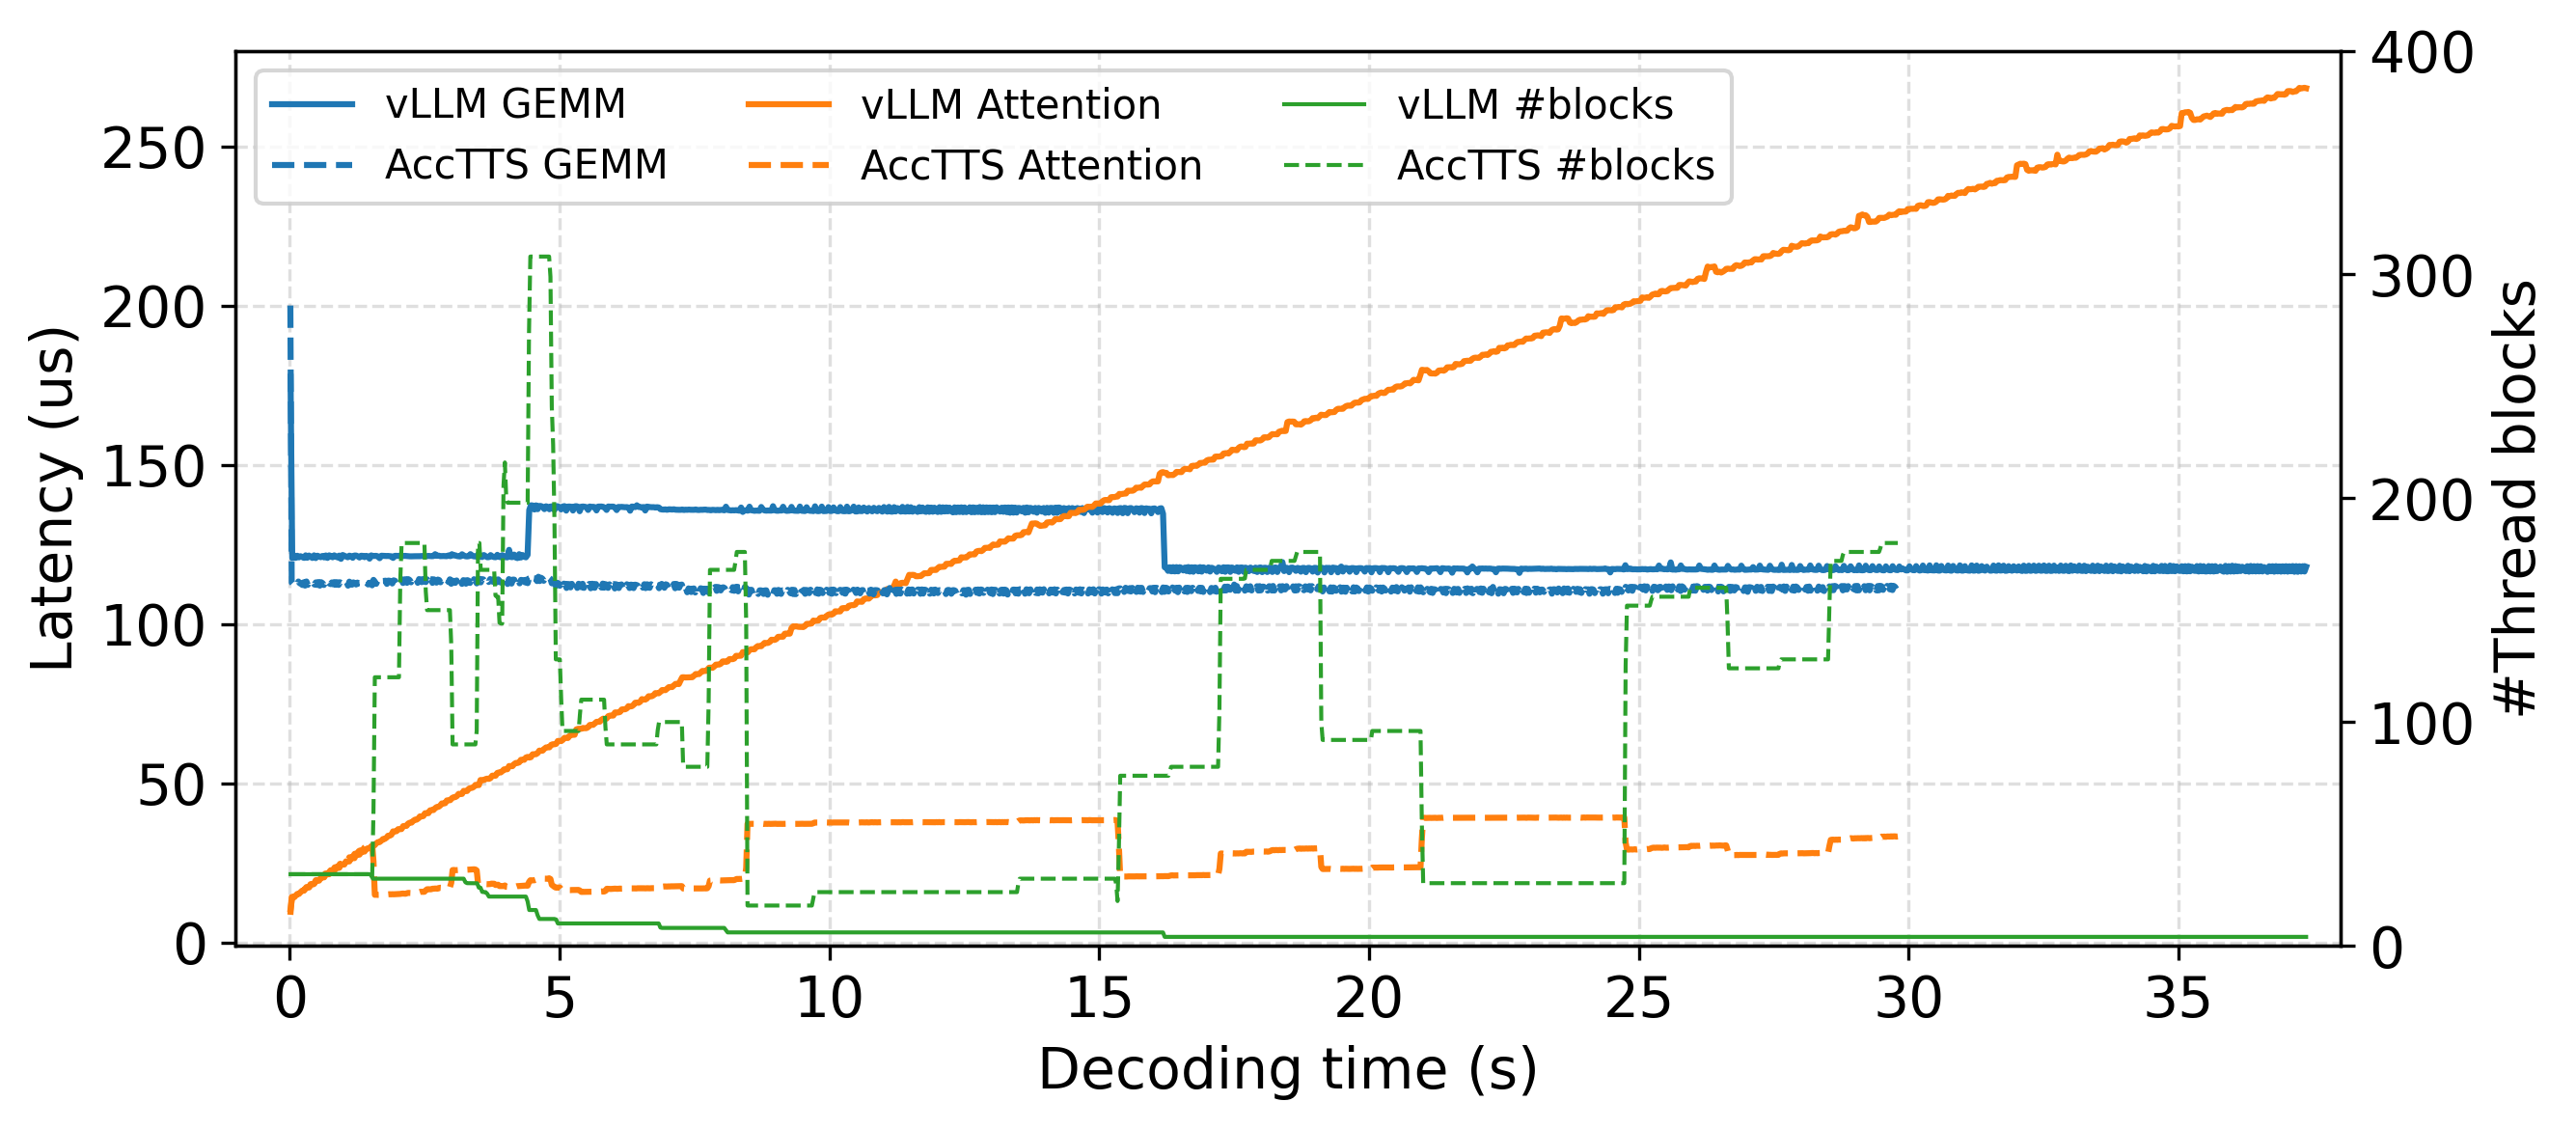

In [35]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)
ax2 = ax.twinx()   # secondary axis: #thread blocks of the attention kernel

# colour = metric, line style = run
MCOLOR = {'GEMM': '#1f77b4', 'Attention': '#ff7f0e', '#blocks': '#2ca02c'}
RSTYLE = {'vLLM': '-', 'AccTTS': '--'}
handles = {}

for name in DATA:
    k = DATA[name]['kernels']
    ls = RSTYLE[name]

    # GEMM latency = graph replay time (left axis)
    g = DATA[name]['graphs']
    gs = g['start'].to_numpy()
    gd = (g['end'] - g['start']).to_numpy().astype(float)
    o = np.argsort(gs)
    xg, yg = binned(gs[o], gd[o])
    handles[(name, 'GEMM')], = ax.plot(xg, yg / 1e3, color=MCOLOR['GEMM'],
                                       lw=1.5, ls=ls, label=f'{name} GEMM')

    # Attention op: FA path (_paged_attn_) early, FD (stage1+stage2) later.
    if name == 'vLLM':
        att = k[k['name'] == '_paged_attn_'].sort_values('start')
        at = att['start'].to_numpy()
        a_lat = att['dur'].to_numpy().astype(float)
        a_blk = att['blocks'].to_numpy().astype(float)
    else:
        s1 = k[k['name'] == '_paged_attn_stage1'].sort_values('start').reset_index(drop=True)
        s2 = k[k['name'] == '_paged_attn_stage2'].sort_values('start').reset_index(drop=True)
        fa = k[k['name'] == '_paged_attn_']
        at = np.concatenate([fa['start'].to_numpy(), s1['start'].to_numpy()])
        a_lat = np.concatenate([fa['dur'].to_numpy().astype(float),
                                s1['dur'].to_numpy().astype(float)
                                + s2['dur'].to_numpy().astype(float)])
        # #thread blocks of the attention compute kernel: FA -> _paged_attn_,
        # FD -> stage1 (the KV-split kernel that creates the parallelism).
        a_blk = np.concatenate([fa['blocks'].to_numpy().astype(float),
                                s1['blocks'].to_numpy().astype(float)])
    o = np.argsort(at)
    xa, ya = binned(at[o], a_lat[o])
    handles[(name, 'Attention')], = ax.plot(xa, ya / 1e3, color=MCOLOR['Attention'],
                                            lw=1.5, ls=ls, label=f'{name} Attention')

    # #thread blocks over time (right axis)
    xb, yb = binned(at[o], a_blk[o])
    handles[(name, '#blocks')], = ax2.plot(xb, yb, color=MCOLOR['#blocks'],
                                           lw=1, ls=ls, label=f'{name} #blocks')

ax.set_xlabel('Decoding time (s)', fontsize=14)
ax.set_ylabel('Latency (us)', fontsize=14)
ax2.set_ylabel('#Thread blocks', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax.set_xlim(-1, 38)
ax.set_ylim(-1, 280)
ax2.set_ylim(0, 400)
ax.grid(ls='--', alpha=0.4); ax.set_axisbelow(True)

# matplotlib fills the legend column-major, so this order gives
# col1 = GEMM (vLLM/AccTTS), col2 = Attention, col3 = #blocks.
order = [('vLLM', 'GEMM'), ('AccTTS', 'GEMM'),
         ('vLLM', 'Attention'), ('AccTTS', 'Attention'),
         ('vLLM', '#blocks'), ('AccTTS', '#blocks')]
hs = [handles[key] for key in order]
ax.legend(hs, [h.get_label() for h in hs], ncol=3, fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / 'latency_breakdown_timeline.png', bbox_inches='tight', dpi=300)
plt.show()